In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pymysql
from db_config import DB_HOST, DB_USER, DB_PASSWD, DB_NAME

try:
    with pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASSWD,
        database=DB_NAME
        # Notice I deleted the DictCursor line here!
    ) as connection:
        query = "SELECT * FROM project_weather_api"
        df = pd.read_sql(query, connection)
        
        # Save it to CSV so we never deal with the DB again tonight
        # df.to_csv("aqi_data.csv", index=False)
        print("Data saved to CSV. Connection closed automatically.")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data saved to CSV. Connection closed automatically.


/var/folders/x9/j5dq5m9n5_ddggn66zklqbv80000gn/T/ipykernel_17130/2979905757.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,ts,lat,lon,humid,rainfall,temp,windspeed
0,1,2026-03-26 21:42:25,13.7264,100.560,75,0,31.2,5.6
1,2,2026-03-26 21:52:26,13.7264,100.560,75,0,31.2,5.6
2,3,2026-03-26 22:12:33,13.6664,100.606,80,0,29.6,9.3
3,4,2026-03-26 22:22:13,13.6664,100.606,80,0,29.6,9.3
4,5,2026-03-26 22:32:47,13.7264,100.560,82,0,29.8,5.6


In [3]:
print(df.columns)
print(df.dtypes)

Index(['id', 'ts', 'lat', 'lon', 'humid', 'rainfall', 'temp', 'windspeed'], dtype='str')
id                    int64
ts           datetime64[us]
lat                 float64
lon                 float64
humid                 int64
rainfall              int64
temp                float64
windspeed           float64
dtype: object


In [4]:
df.nunique()

id           1118
ts           1118
lat             3
lon             3
humid          34
rainfall        6
temp           70
windspeed      91
dtype: int64

In [5]:
df.describe()

,id,ts,lat,lon,humid,rainfall,temp,windspeed
count,1118.000000,1118,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000
mean,559.500000,2026-03-30 21:09:29.172629,13.726810,100.560203,66.920394,0.050089,31.743828,6.448032
min,1.000000,2026-03-26 21:42:25,13.666400,100.560000,45.000000,0.000000,27.000000,2.000000
25%,280.250000,2026-03-28 22:35:04,13.726400,100.560000,61.000000,0.000000,31.000000,3.200000
50%,559.500000,2026-03-30 21:07:34,13.726400,100.560000,66.000000,0.000000,32.000000,5.600000
75%,838.750000,2026-04-01 19:40:04,13.726400,100.560000,78.000000,0.000000,32.800000,9.400000
max,1118.000000,2026-04-10 21:52:09,13.919200,100.606000,85.000000,5.000000,37.000000,13.000000
std,322.883106,NaN,0.010301,0.003031,10.987904,0.398290,2.495043,3.514644


In [6]:
df.isnull().sum()

id           0
ts           0
lat          0
lon          0
humid        0
rainfall     0
temp         0
windspeed    0
dtype: int64

Empty DataFrame
Columns: [id, ts, lat, lon, humid, rainfall, temp, windspeed]
Index: []


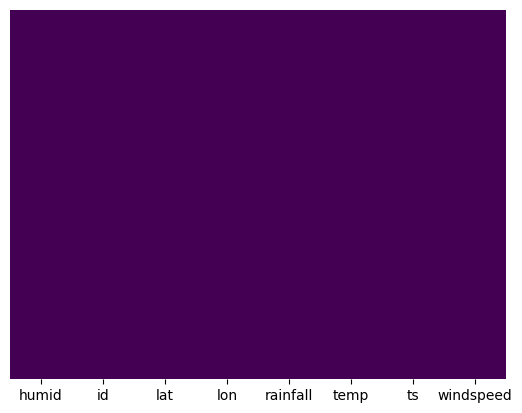

In [7]:

check_cols = [c for c in df.columns if c != 'rainfall']

mask = df.isnull() | (df[check_cols] == 0) | (df == "")

# Filter the original dataframe to show only rows where ANY column is True
print(df[mask.any(axis=1)])
sns.heatmap(mask, cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [8]:
df['ts'] = pd.to_datetime(df['ts'])

In [9]:
# Calculate the mode for lat and lon
lat_mode = df['lat'].mode()[0]
lon_mode = df['lon'].mode()[0]

# Fill any value that is NOT the mode (including NaNs or incorrect coords)
# We basically set the entire column to the mode value to ensure consistency
df['lat'] = lat_mode
df['lon'] = lon_mode

print(f"Fixed coordinates to Mode: {lat_mode}, {lon_mode}")

Fixed coordinates to Mode: 13.7264, 100.56


In [10]:
# Identify the mode
lat_mode = df['lat'].mode()[0]
lon_mode = df['lon'].mode()[0]

# If the value is NOT the mode, replace it with the mode
df.loc[df['lat'] != lat_mode, 'lat'] = lat_mode
df.loc[df['lon'] != lon_mode, 'lon'] = lon_mode

In [11]:
df.nunique()

id           1118
ts           1118
lat             1
lon             1
humid          34
rainfall        6
temp           70
windspeed      91
dtype: int64

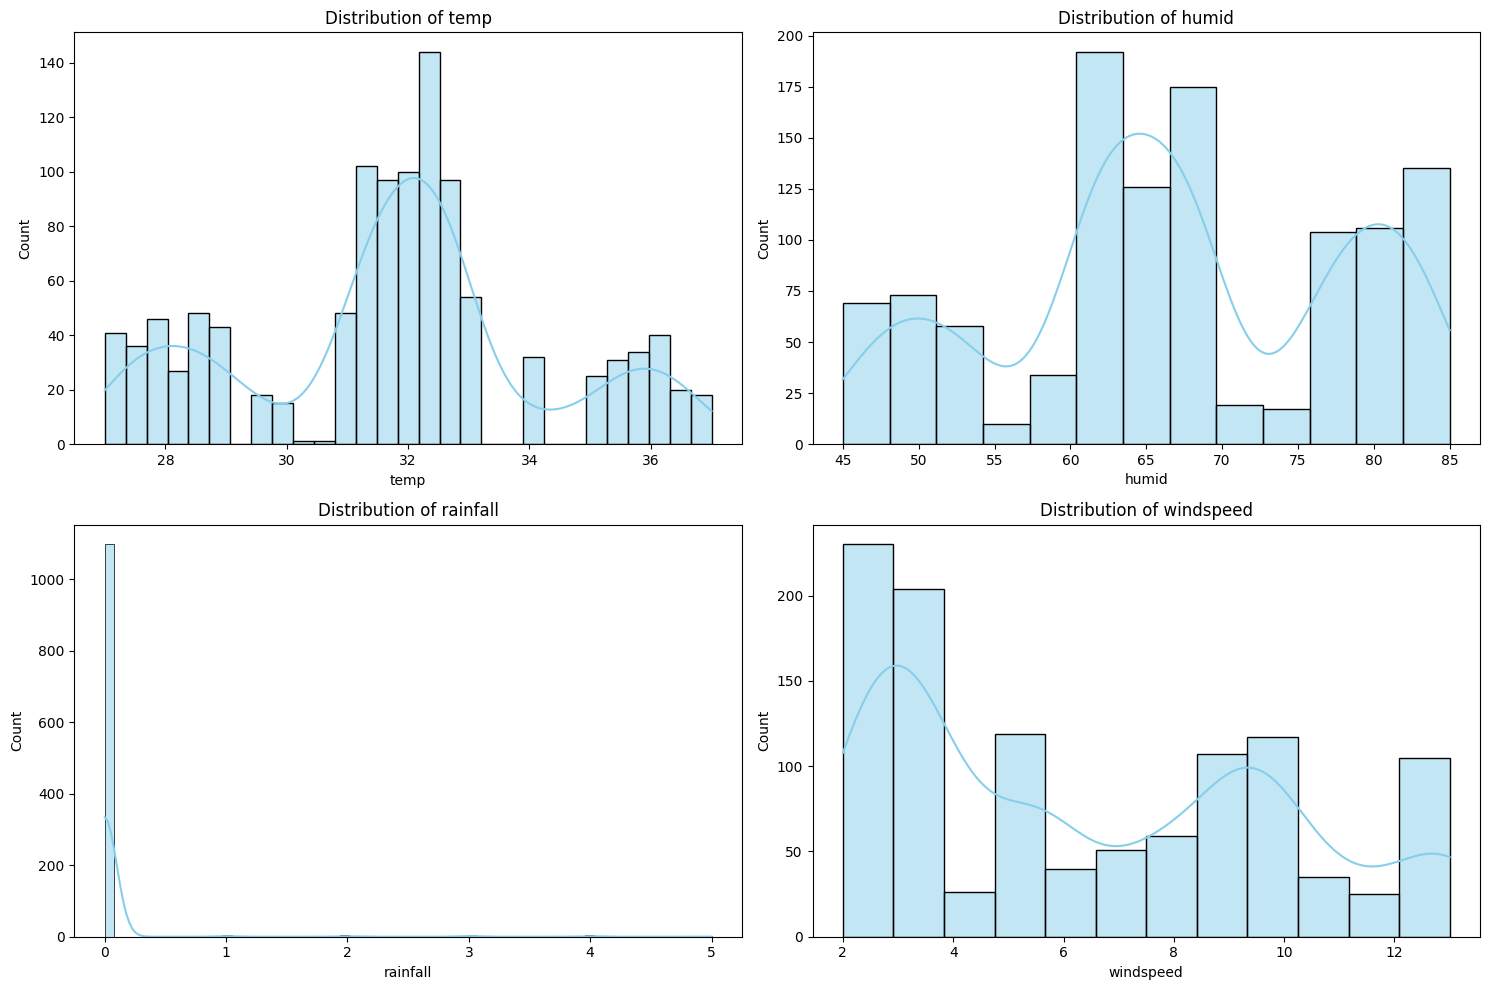

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of sensor columns to visualize
sensors = ['temp', 'humid', 'rainfall', 'windspeed']

plt.figure(figsize=(15, 10))
for i, col in enumerate(sensors, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

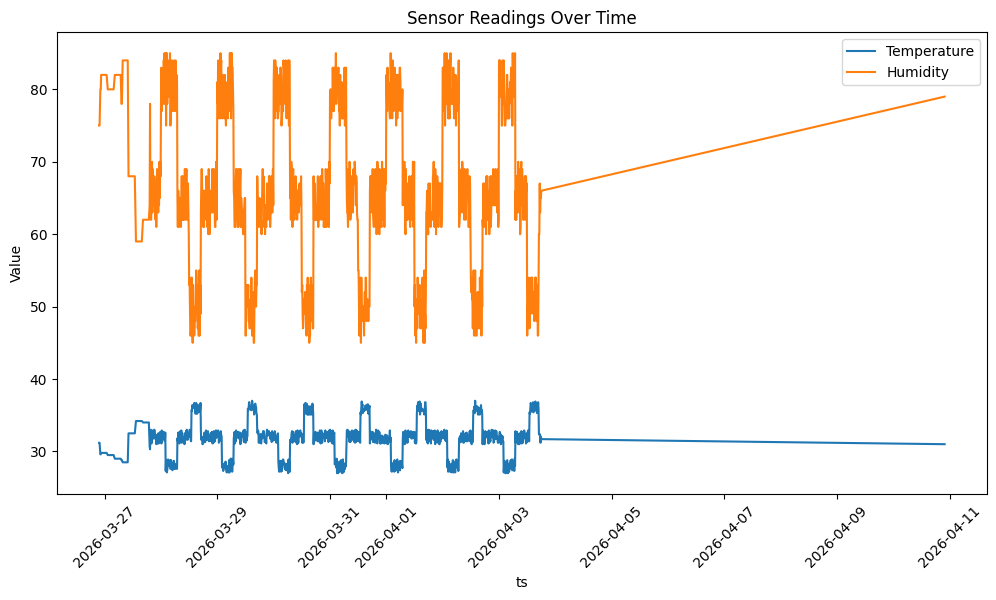

In [13]:
# Ensure ts is a datetime object
df['ts'] = pd.to_datetime(df['ts'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='ts', y='temp', label='Temperature')
sns.lineplot(data=df, x='ts', y='humid', label='Humidity')
plt.title('Sensor Readings Over Time')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()
plt.show()

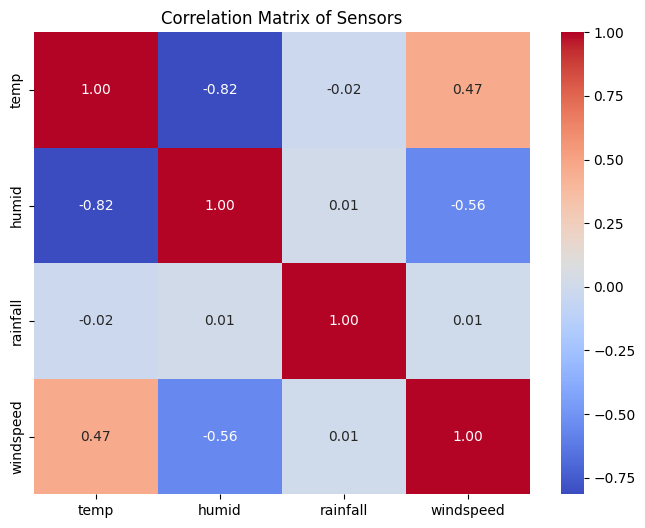

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[sensors].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sensors')
plt.show()

In [15]:
# Drop the id column
df = df.drop(columns=['id'])

# Verify it's gone
print(df.head())


                   ts      lat     lon  humid  rainfall  temp  windspeed
0 2026-03-26 21:42:25  13.7264  100.56     75         0  31.2        5.6
1 2026-03-26 21:52:26  13.7264  100.56     75         0  31.2        5.6
2 2026-03-26 22:12:33  13.7264  100.56     80         0  29.6        9.3
3 2026-03-26 22:22:13  13.7264  100.56     80         0  29.6        9.3
4 2026-03-26 22:32:47  13.7264  100.56     82         0  29.8        5.6


In [16]:
# Drop the lat and lon columns
df = df.drop(columns=['lat'])
df = df.drop(columns=['lon'])
# Verify they're gone
print(df.head())


                   ts  humid  rainfall  temp  windspeed
0 2026-03-26 21:42:25     75         0  31.2        5.6
1 2026-03-26 21:52:26     75         0  31.2        5.6
2 2026-03-26 22:12:33     80         0  29.6        9.3
3 2026-03-26 22:22:13     80         0  29.6        9.3
4 2026-03-26 22:32:47     82         0  29.8        5.6


In [17]:
df.to_csv('weather_data.csv', index=False)
print("Data saved to weather_data.csv")


Data saved to weather_data.csv
